# Day 1 — Data Understanding

**Goal:** Load all 5 datasets, understand their structure, identify join keys, and document findings.

**DO NOT** clean, model, or merge anything yet. Just look.

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Define paths
DATA_PATH = "../data/raw"
print(f"Looking for data in: {DATA_PATH}")
print(f"Files found: {os.listdir(DATA_PATH)}")

Looking for data in: ../data/raw
Files found: ['employee_attrition.csv', 'essential_skills.csv', 'hr_performance_engagement.csv', 'occupation_data.csv', 'software_skills.csv']


## 1. Employee Attrition Dataset

In [4]:
# Load attrition data
attrition_df = pd.read_csv(f"{DATA_PATH}/employee_attrition.csv")

print("=" * 80)
print("EMPLOYEE ATTRITION DATASET")
print("=" * 80)

# Basic info
print(f"\nShape: {attrition_df.shape}")
print(f"\nColumns: {list(attrition_df.columns)}")

# Data types
print("\nData Types:")
print(attrition_df.dtypes)

# First few rows
print("\nFirst 5 rows:")
print(attrition_df.head())

# Missing values
print("\nMissing Values:")
missing = attrition_df.isnull().sum().sort_values(ascending=False)
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values")

# Duplicates
print(f"\nDuplicate rows: {attrition_df.duplicated().sum()}")

# ID columns
print("\nPotential ID columns:")
id_cols = [c for c in attrition_df.columns if 'id' in c.lower()]
if id_cols:
    for col in id_cols:
        print(f"  {col}: {attrition_df[col].nunique()} unique values")
        print(f"    Range: {attrition_df[col].min()} to {attrition_df[col].max()}")
else:
    print("  No obvious ID column found")

# Target variable balance
if 'Attrition' in attrition_df.columns:
    print("\nTarget Variable (Attrition) Balance:")
    balance = attrition_df['Attrition'].value_counts(normalize=True) * 100
    for val, pct in balance.items():
        print(f"  {val}: {pct:.2f}%")
elif 'attrition' in attrition_df.columns.str.lower():
    col_name = [c for c in attrition_df.columns if c.lower() == 'attrition'][0]
    print(f"\nTarget Variable ({col_name}) Balance:")
    balance = attrition_df[col_name].value_counts(normalize=True) * 100
    for val, pct in balance.items():
        print(f"  {val}: {pct:.2f}%")

# Numeric statistics
print("\nNumeric Summary:")
print(attrition_df.describe())

EMPLOYEE ATTRITION DATASET

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int

## 2. HR Performance & Engagement Dataset

In [5]:
# Load performance data (might be named differently)
perf_files = [f for f in os.listdir(DATA_PATH) if 'performance' in f.lower() or 'engagement' in f.lower()]
if perf_files:
    perf_file = perf_files[0]
    perf_df = pd.read_csv(f"{DATA_PATH}/{perf_file}")
    
    print("=" * 80)
    print(f"HR PERFORMANCE & ENGAGEMENT DATASET ({perf_file})")
    print("=" * 80)
    
    print(f"\nShape: {perf_df.shape}")
    print(f"\nColumns: {list(perf_df.columns)}")
    print("\nData Types:")
    print(perf_df.dtypes)
    print("\nFirst 5 rows:")
    print(perf_df.head())
    print("\nMissing Values:")
    missing = perf_df.isnull().sum().sort_values(ascending=False)
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("No missing values")
    
    print(f"\nDuplicate rows: {perf_df.duplicated().sum()}")
    print("\nNumeric Summary:")
    print(perf_df.describe())
else:
    print("No performance/engagement file found")
    perf_df = None

HR PERFORMANCE & ENGAGEMENT DATASET (hr_performance_engagement.csv)

Shape: (5000, 13)

Columns: ['Employee ID', 'Name', 'Department', 'Job Role', 'Performance Score', 'KPI Score', 'Attendance (%)', 'Peer Rating', 'Task Completion (%)', 'Work Hours Logged', 'Manager Feedback', 'Training Hours', 'Promotion Eligibility']

Data Types:
Employee ID                int64
Name                      object
Department                object
Job Role                  object
Performance Score          int64
KPI Score                float64
Attendance (%)           float64
Peer Rating              float64
Task Completion (%)      float64
Work Hours Logged          int64
Manager Feedback         float64
Training Hours             int64
Promotion Eligibility     object
dtype: object

First 5 rows:
   Employee ID            Name Department             Job Role  \
0       376063  Manikya Badami      Sales      Sales Executive   
1       810690      Zara Mahal  Marketing  Marketing Executive   
2       52

## 3. Occupation Data (Role Master)

In [6]:
# Load occupation data
occ_df = pd.read_csv(f"{DATA_PATH}/occupation_data.csv")

print("=" * 80)
print("OCCUPATION DATA (Role Master)")
print("=" * 80)

print(f"\nShape: {occ_df.shape}")
print(f"\nColumns: {list(occ_df.columns)}")
print("\nData Types:")
print(occ_df.dtypes)
print("\nFirst 10 rows:")
print(occ_df.head(10))
print("\nMissing Values:")
missing = occ_df.isnull().sum().sort_values(ascending=False)
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values")
print(f"\nDuplicate rows: {occ_df.duplicated().sum()}")
print(f"\nUnique occupations: {occ_df.shape[0]}")

OCCUPATION DATA (Role Master)

Shape: (1016, 3)

Columns: ['O*NET-SOC Code', 'Title', 'Description']

Data Types:
O*NET-SOC Code    object
Title             object
Description       object
dtype: object

First 10 rows:
  O*NET-SOC Code                                Title  \
0     11-1011.00                     Chief Executives   
1     11-1011.03        Chief Sustainability Officers   
2     11-1021.00      General and Operations Managers   
3     11-1031.00                          Legislators   
4     11-2011.00  Advertising and Promotions Managers   
5     11-2021.00                   Marketing Managers   
6     11-2022.00                       Sales Managers   
7     11-2032.00            Public Relations Managers   
8     11-2033.00                 Fundraising Managers   
9     11-3012.00     Administrative Services Managers   

                                         Description  
0  Determine and formulate policies and provide o...  
1  Communicate and coordinate with manageme

## 4. Essential Skills Dataset

In [7]:
# Load essential skills
ess_skills_df = pd.read_csv(f"{DATA_PATH}/essential_skills.csv")

print("=" * 80)
print("ESSENTIAL SKILLS DATASET")
print("=" * 80)

print(f"\nShape: {ess_skills_df.shape}")
print(f"\nColumns: {list(ess_skills_df.columns)}")
print("\nData Types:")
print(ess_skills_df.dtypes)
print("\nFirst 10 rows:")
print(ess_skills_df.head(10))
print("\nMissing Values:")
missing = ess_skills_df.isnull().sum().sort_values(ascending=False)
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values")
print(f"\nDuplicate rows: {ess_skills_df.duplicated().sum()}")
print(f"\nTotal rows: {len(ess_skills_df)}")
print(f"Sample skills: {ess_skills_df.iloc[0:5]}")

ESSENTIAL SKILLS DATASET

Shape: (18200, 15)

Columns: ['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']

Data Types:
O*NET-SOC Code         object
Title                  object
Element ID             object
Element Name           object
Scale ID               object
Scale Name             object
Data Value            float64
N                       int64
Standard Error        float64
Lower CI Bound        float64
Upper CI Bound        float64
Recommend Suppress     object
Not Relevant           object
Date                   object
Domain Source          object
dtype: object

First 10 rows:
  O*NET-SOC Code             Title Element ID           Element Name Scale ID  \
0     11-1011.00  Chief Executives    2.A.1.a  Reading Comprehension       IM   
1     11-1011.00  Chief Executives    2.A.1.a  Reading Comprehension  

## 5. Software Skills Dataset

In [8]:
# Load software skills
soft_skills_df = pd.read_csv(f"{DATA_PATH}/software_skills.csv")

print("=" * 80)
print("SOFTWARE SKILLS DATASET")
print("=" * 80)

print(f"\nShape: {soft_skills_df.shape}")
print(f"\nColumns: {list(soft_skills_df.columns)}")
print("\nData Types:")
print(soft_skills_df.dtypes)
print("\nFirst 10 rows:")
print(soft_skills_df.head(10))
print("\nMissing Values:")
missing = soft_skills_df.isnull().sum().sort_values(ascending=False)
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values")
print(f"\nDuplicate rows: {soft_skills_df.duplicated().sum()}")
print(f"\nTotal rows: {len(soft_skills_df)}")

SOFTWARE SKILLS DATASET

Shape: (31821, 7)

Columns: ['O*NET-SOC Code', 'Title', 'Workplace Example', 'Element ID', 'Element Name', 'Hot Technology', 'In Demand']

Data Types:
O*NET-SOC Code       object
Title                object
Workplace Example    object
Element ID           object
Element Name         object
Hot Technology       object
In Demand            object
dtype: object

First 10 rows:
  O*NET-SOC Code             Title  \
0     11-1011.00  Chief Executives   
1     11-1011.00  Chief Executives   
2     11-1011.00  Chief Executives   
3     11-1011.00  Chief Executives   
4     11-1011.00  Chief Executives   
5     11-1011.00  Chief Executives   
6     11-1011.00  Chief Executives   
7     11-1011.00  Chief Executives   
8     11-1011.00  Chief Executives   
9     11-1011.00  Chief Executives   

                               Workplace Example Element ID  \
0                                  Adobe Acrobat    2.E.5.b   
1                                AdSense Tracker    2

## Summary Report

In [10]:
# Create summary report
summary_report = f"""
================================================================================
DATA UNDERSTANDING SUMMARY
================================================================================

1. EMPLOYEE ATTRITION
   • Size: {attrition_df.shape[0]} employees × {attrition_df.shape[1]} columns
   • Purpose: Feeds attrition ML model
   • Primary Key: EmployeeID (if exists)
   • Missing Data: {attrition_df.isnull().sum().sum()} total nulls
   • Target Balance: Check attrition distribution above

2. HR PERFORMANCE & ENGAGEMENT
   • Size: {perf_df.shape[0] if perf_df is not None else 'NOT FOUND'} rows × {perf_df.shape[1] if perf_df is not None else 0} columns
   • Purpose: Engagement analytics, employee satisfaction tracking
   • Join Key: Should link to EmployeeID from attrition table
   • Missing Data: {perf_df.isnull().sum().sum() if perf_df is not None else 0} total nulls

3. OCCUPATION DATA
   • Size: {occ_df.shape[0]} roles × {occ_df.shape[1]} columns
   • Purpose: Master reference table for job roles
   • Primary Key: Likely 'OccupationID' or similar
   • Missing Data: {occ_df.isnull().sum().sum()} total nulls

4. ESSENTIAL SKILLS
   • Size: {ess_skills_df.shape[0]} rows × {ess_skills_df.shape[1]} columns
   • Purpose: Maps required skills to job roles
   • Join Key: OccupationID → occupation_data
   • Missing Data: {ess_skills_df.isnull().sum().sum()} total nulls

5. SOFTWARE SKILLS
   • Size: {soft_skills_df.shape[0]} rows × {soft_skills_df.shape[1]} columns
   • Purpose: Maps software/tools to job roles
   • Join Key: OccupationID → occupation_data
   • Missing Data: {soft_skills_df.isnull().sum().sum()} total nulls

================================================================================
NEXT STEPS (Day 1 continues):
================================================================================
1. Data Validation (02_data_validation.ipynb)
   → Check for invalid values, ranges, categories

2. Data Cleaning (03_data_cleaning.ipynb)
   → Handle missing values, fix types, standardize names

3. Data Relationships (04_data_relationships.ipynb)
   → Confirm join keys, test merges, document relationships

================================================================================
"""

print(summary_report)

# Save report
with open("../data_understanding_report.txt", "w", encoding="utf-8") as f:
    f.write(summary_report)

print("✓ Report saved to ../data_understanding_report.txt")


DATA UNDERSTANDING SUMMARY

1. EMPLOYEE ATTRITION
   • Size: 1470 employees × 35 columns
   • Purpose: Feeds attrition ML model
   • Primary Key: EmployeeID (if exists)
   • Missing Data: 0 total nulls
   • Target Balance: Check attrition distribution above

2. HR PERFORMANCE & ENGAGEMENT
   • Size: 5000 rows × 13 columns
   • Purpose: Engagement analytics, employee satisfaction tracking
   • Join Key: Should link to EmployeeID from attrition table
   • Missing Data: 0 total nulls

3. OCCUPATION DATA
   • Size: 1016 roles × 3 columns
   • Purpose: Master reference table for job roles
   • Primary Key: Likely 'OccupationID' or similar
   • Missing Data: 0 total nulls

4. ESSENTIAL SKILLS
   • Size: 18200 rows × 15 columns
   • Purpose: Maps required skills to job roles
   • Join Key: OccupationID → occupation_data
   • Missing Data: 9100 total nulls

5. SOFTWARE SKILLS
   • Size: 31821 rows × 7 columns
   • Purpose: Maps software/tools to job roles
   • Join Key: OccupationID → occupat

## Visualization: Data Overview

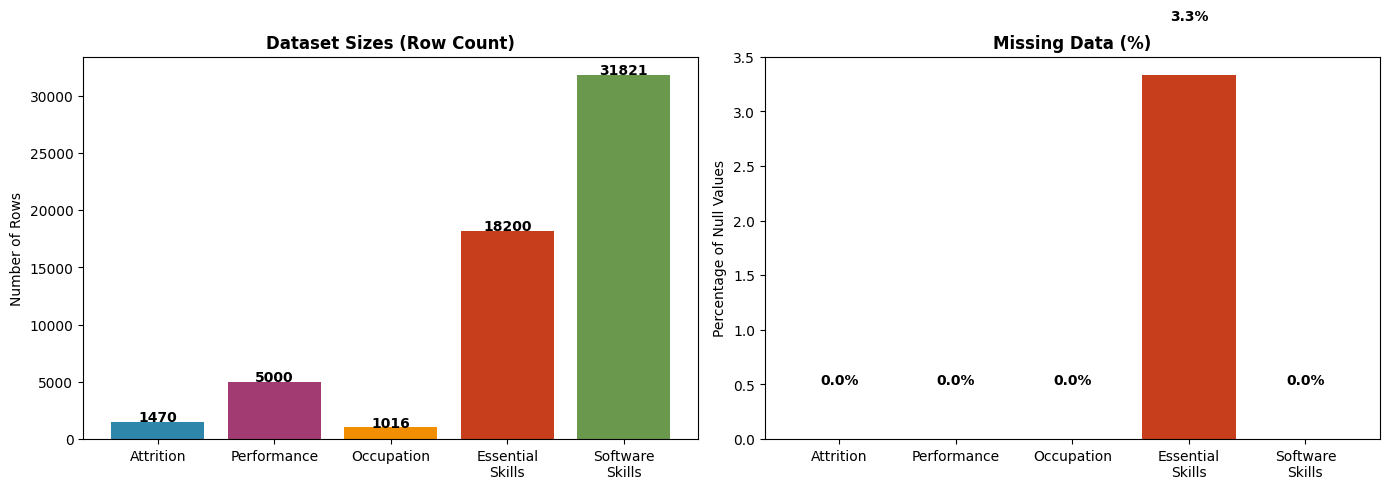

✓ Visualization saved to ../data_overview.png


In [11]:
# Create visualization showing dataset sizes
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Dataset sizes
datasets = ['Attrition', 'Performance', 'Occupation', 'Essential\nSkills', 'Software\nSkills']
sizes = [
    attrition_df.shape[0],
    perf_df.shape[0] if perf_df is not None else 0,
    occ_df.shape[0],
    ess_skills_df.shape[0],
    soft_skills_df.shape[0]
]

ax[0].bar(datasets, sizes, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E'])
ax[0].set_title('Dataset Sizes (Row Count)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Number of Rows')
for i, v in enumerate(sizes):
    ax[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Null percentages
null_pcts = [
    (attrition_df.isnull().sum().sum() / (attrition_df.shape[0] * attrition_df.shape[1]) * 100),
    (perf_df.isnull().sum().sum() / (perf_df.shape[0] * perf_df.shape[1]) * 100 if perf_df is not None else 0),
    (occ_df.isnull().sum().sum() / (occ_df.shape[0] * occ_df.shape[1]) * 100),
    (ess_skills_df.isnull().sum().sum() / (ess_skills_df.shape[0] * ess_skills_df.shape[1]) * 100),
    (soft_skills_df.isnull().sum().sum() / (soft_skills_df.shape[0] * soft_skills_df.shape[1]) * 100)
]

ax[1].bar(datasets, null_pcts, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E'])
ax[1].set_title('Missing Data (%)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Percentage of Null Values')
for i, v in enumerate(null_pcts):
    ax[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to ../data_overview.png")

In [12]:
print("\n✓ DAY 1 DATA UNDERSTANDING COMPLETE")
print("\nNext: Run 02_data_validation.ipynb")


✓ DAY 1 DATA UNDERSTANDING COMPLETE

Next: Run 02_data_validation.ipynb
